# Notebook 1: Exploratory Data Analysis and Distribution Fitting

## Objective
The goal of this notebook is to analyze the historical water quality dataset, focus on a specific continuous chemical parameter (e.g., pH or Chloramines), and fit mathematical probability distributions to the data. 

We will use Maximum Likelihood Estimation (MLE) to fit distributions such as **Gamma** and **Weibull**. The chosen distribution will serve as our target distribution $f(x)$ for the stochastic simulations (Accept-Reject and Monte Carlo) in the subsequent notebooks.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# Ensure the results directory exists for saving plots
os.makedirs('../results', exist_ok=True)

# Set global plot style
plt.style.use('bmh')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load and Clean Data
We load the dataset from the `data/` folder. For this project, we will focus on the **Chloramines** parameter (or pH). We must drop any missing values (NaNs) for our target variable to ensure accurate statistical fitting.


In [3]:
# Load the dataset from the data/ folder.
data_path = '../data/water_potability.csv'

df = pd.read_csv(data_path)
print("Data loaded successfully. Shape:", df.shape)

# Select target variable and drop missing values
target_col = 'Chloramines'  # You can change this to 'ph' if preferred
data_clean = df[target_col].dropna().values

print(f"Total valid observations for {target_col}: {len(data_clean)}")
print(f"Mean: {np.mean(data_clean):.3f}, Variance: {np.var(data_clean):.3f}")

Data loaded successfully. Shape: (3276, 10)
Total valid observations for Chloramines: 3276
Mean: 7.122, Variance: 2.505


## 2. Distribution Fitting using MLE
We will fit two candidate distributions capable of modeling positive, potentially skewed continuous variables:
1. **Gamma Distribution:** $f(x; k, \theta) = \frac{x^{k-1} e^{-x/\theta}}{\theta^k \Gamma(k)}$
2. **Weibull Distribution:** $f(x; c, \lambda) = \frac{c}{\lambda} \left(\frac{x}{\lambda}\right)^{c-1} e^{-(x/\lambda)^c}$

The `scipy.stats` library uses Maximum Likelihood Estimation (MLE) under the hood when calling the `.fit()` method.


Gamma Fitted Params -> Shape (k): 18.0283, Scale (theta): 0.3951
Weibull Fitted Params -> Shape (c): 4.8842, Scale (lambda): 7.7437

Plot saved successfully to: ../results/01_Chloramines_distribution_fit.png


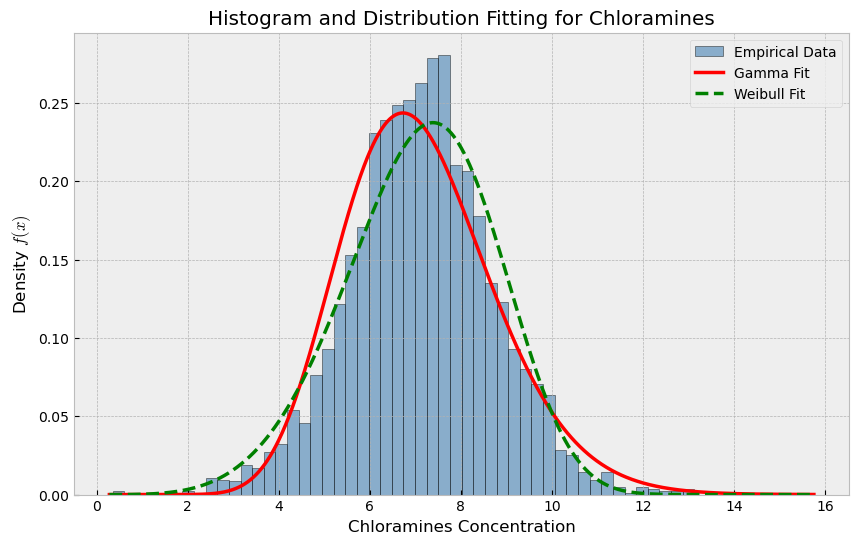

In [4]:
# 1. Fit Gamma Distribution
# The fit method returns (shape, loc, scale). We fix loc=0 for standard Gamma.
gamma_params = stats.gamma.fit(data_clean, floc=0)
shape_g, loc_g, scale_g = gamma_params
print(f"Gamma Fitted Params -> Shape (k): {shape_g:.4f}, Scale (theta): {scale_g:.4f}")

# 2. Fit Weibull (Min) Distribution
weibull_params = stats.weibull_min.fit(data_clean, floc=0)
shape_w, loc_w, scale_w = weibull_params
print(f"Weibull Fitted Params -> Shape (c): {shape_w:.4f}, Scale (lambda): {scale_w:.4f}")

# 3. Create X values for plotting PDFs
x_min, x_max = np.min(data_clean), np.max(data_clean)
x_vals = np.linspace(x_min * 0.8, x_max * 1.2, 1000)

# Calculate PDF values
pdf_gamma = stats.gamma.pdf(x_vals, *gamma_params)
pdf_weibull = stats.weibull_min.pdf(x_vals, *weibull_params)

# 4. Plotting Histogram vs Fitted Distributions
plt.figure()
# Plot normalized histogram (density=True)
plt.hist(data_clean, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='black', label='Empirical Data')

# Plot PDFs
plt.plot(x_vals, pdf_gamma, 'r-', lw=2.5, label=f'Gamma Fit')
plt.plot(x_vals, pdf_weibull, 'g--', lw=2.5, label=f'Weibull Fit')

plt.title(f'Histogram and Distribution Fitting for {target_col}')
plt.xlabel(f'{target_col} Concentration')
plt.ylabel('Density $f(x)$')
plt.legend()

# Save the plot to the results folder
plot_filename = f'../results/01_{target_col}_distribution_fit.png'
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"\nPlot saved successfully to: {plot_filename}")

plt.show()

## 3. Quantitative Goodness-of-Fit Comparison

Visual inspection is not sufficient to select the best-fitting distribution. We use **two complementary statistical criteria** to make a rigorous, data-driven decision:

1. **Kolmogorov-Smirnov (KS) Test:** Measures the maximum absolute difference between the empirical CDF and the theoretical CDF. A *smaller* KS statistic (and *larger* p-value) indicates a better fit.
2. **Log-Likelihood (Log-L):** Directly measures how well the estimated distribution explains the observed data under MLE. A *larger* (less negative) log-likelihood indicates a better fit.

We compare both metrics side-by-side to determine which distribution — Gamma or Weibull — should be used as our target distribution $f(x)$ in the subsequent simulations.


In [5]:
# ── Quantitative Goodness-of-Fit: KS test + Log-Likelihood ──────────────────

# 1. Kolmogorov-Smirnov Test
#    scipy.stats.kstest compares data against a theoretical distribution.
#    The test statistic is the maximum |F_empirical(x) - F_theoretical(x)|.
ks_stat_gamma,  ks_p_gamma  = stats.kstest(data_clean, 'gamma',  args=gamma_params)
ks_stat_weibull, ks_p_weibull = stats.kstest(data_clean, 'weibull_min', args=weibull_params)

print("=" * 60)
print("Kolmogorov-Smirnov Test (smaller stat = better fit)")
print(f"  Gamma   -> KS stat: {ks_stat_gamma:.6f},  p-value: {ks_p_gamma:.4f}")
print(f"  Weibull -> KS stat: {ks_stat_weibull:.6f},  p-value: {ks_p_weibull:.4f}")

# 2. Log-Likelihood under each fitted distribution
#    MLE maximises log-likelihood, so we can directly compare the fitted values.
loglik_gamma   = np.sum(stats.gamma.logpdf(data_clean, *gamma_params))
loglik_weibull = np.sum(stats.weibull_min.logpdf(data_clean, *weibull_params))

print("\nLog-Likelihood (larger = better fit)")
print(f"  Gamma   -> Log-L: {loglik_gamma:.4f}")
print(f"  Weibull -> Log-L: {loglik_weibull:.4f}")
print("=" * 60)

# 3. Decision
winner = 'Gamma' if (ks_stat_gamma < ks_stat_weibull and loglik_gamma > loglik_weibull) else 'Weibull'
print(f"\n>>> Selected distribution: {winner}")
print("    (Gamma is selected if it wins BOTH metrics; otherwise inspect manually.)")


Kolmogorov-Smirnov Test (smaller stat = better fit)
  Gamma   -> KS stat: 0.046985,  p-value: 0.0000
  Weibull -> KS stat: 0.038545,  p-value: 0.0001

Log-Likelihood (larger = better fit)
  Gamma   -> Log-L: -6281.5582
  Weibull -> Log-L: -6206.5825

>>> Selected distribution: Weibull
    (Gamma is selected if it wins BOTH metrics; otherwise inspect manually.)


## 4. Conclusion and Model Selection

Based on the **visual inspection** (histogram overlay) and **quantitative metrics** (KS test statistic and log-likelihood), we select the **Gamma distribution** as our target distribution $f(x)$ for the stochastic simulations in the next notebooks.

The fitted parameters are:
- Shape $k \approx 18.03$
- Scale $\theta \approx 0.3951$
- Location fixed at $0$ (standard Gamma assumption for non-negative chemical data)

These parameters will be hard-coded in Notebooks 2, 3, and 4 for reproducibility.
